# §5.3 — Bicapa estratificada: figuras finales

Notebook de **producción**, recortado a una sola afirmación:

> La segregación espacial destruye el medio efectivo que la mezcla composicional preserva.

Reutiliza exactamente los mismos tests de §5.2 y obtiene la respuesta opuesta. **No hay ningún
parámetro ajustado**: se eliminaron $\zeta$, $\alpha$, $m_c$, la ley $t^*\propto d^2$ y la inversión
del espesor, porque los datos actuales no los sostienen (ver la nota al final).

| | Figura | Afirmación |
|---|---|---|
| 1 | `L1` familia $\eta(\theta;m)$ | El perfil tiene estructura en dos escalas angulares |
| 2 | `L2` colapso de autosimilitud | No existe $\ell^*$ efectivo — mismo test que §5.2, resultado opuesto |
| 3 | `L3` escalares vs profundidad | $\rho(m)$ sobrepasa a ambos constituyentes; selectividad en profundidad |
| 4 | `L4` contraste tardío | El compuerteo temporal extiende la profundidad de sondeo |

**Dos cambios metodológicos respecto al notebook exploratorio**, ambos forzados por la estructura
de dos escalas:

1. **No se reporta una FWHM.** Para un perfil con espiga estrecha sobre pedestal ancho, el cruce a
   media altura salta entre rasgos y produce una serie no monótona que no es interpretable como un
   ancho. Se sustituye por el primer momento $\theta_c$ y por dos razones de forma a ángulos fijos.
2. **El gate se hace contra §5.2, no contra §5.1.** La especie BOT es exactamente el extremo
   $\alpha=1$ del barrido de mezclas (mismo $\mu_s$, mismo $\ell^*$); §5.1 corre a $\mu_s$ distinto
   y compararse con él es el mismo error del `matched_ref`.

## 0 — Entorno y convenciones

In [15]:
import sys, os, pathlib, re
sys.path.append(os.path.abspath("../../"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass, field
from scipy import stats

from utils.loaders import load_sweep
from utils.styles import apply, TEXTWIDTH_IN, DOC_FONTSIZE, COL
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut, azimuthal_average

FIGDIR = pathlib.Path("figs_tesis_capas")
FIGDIR.mkdir(exist_ok=True)

save_path      = "/Users/niaggar/Results"
folder_layers  = "study_two_layers__PLIN__beam2500"
folder_mixture = "study_mixture_layer__PLIN__beam2500"     # fuente de los controles

N_MEDIUM   = 1.33
WAVELENGTH = 0.514
k          = 2 * np.pi * N_MEDIUM / WAVELENGTH
V_UM_FS    = 0.299792458 / N_MEDIUM        # velocidad en el medio [um/fs]

eps = 1e-30


@dataclass
class GroupedZ:
    z: float
    mult: float
    replicas_keys: list = field(default_factory=list)
    name: str = ""

    def __post_init__(self):
        self.replicas_keys = sorted(self.replicas_keys)
        if not self.name:
            self.name = rf"$m={self.mult:.1f}$"

In [16]:
# ===========================================================================
# Convenciones (identicas a 5.2 donde aplica)
# ===========================================================================
CONV = dict(
    phi_main       = 0,          # corte phi = 0
    channel_main   = "co",       # lineal co-polarizado
    th_full_mrad   = 6.0,        # ventana del cono completo
    th_apex_mrad   = 1.0,        # zoom del apice
    x_lo           = 0.25,       # niveles del invariante de forma S
    x_hi           = 0.75,
    q_min_baseline = 25.0,       # mediana de cola, q anclado a l*_bot
    n_apex_bins    = 3,
    conf           = 0.975,
)
PHI, CH = CONV["phi_main"], CONV["channel_main"]


def t_ci(n, conf=CONV["conf"]):
    return stats.t.ppf(conf, n - 1)


print(f"t(0.975, 4) = {t_ci(5):.3f}")

t(0.975, 4) = 2.776


## 1 — Utilidades de reducción

Idénticas a §5.2 salvo por los escalares, que se eligen para ser robustos a un perfil de dos escalas.
`theta_c` es el primer momento del exceso $\eta-1$: está siempre definido, no depende de ningún
cruce, y para un cono de una sola escala es proporcional a su anchura — que es justo lo que necesita
el test de autosimilitud.

In [17]:
# ===========================================================================
# Stitching, linea base y perfiles
# ===========================================================================
def load_stitched(lstar, th1, g1, th2, g2, key, warn=0.05):
    theta_1 = th1[-1]
    ov = (th2 >= 0.9 * theta_1) & (th2 <= theta_1)
    if ov.any():
        resid = np.abs(g2[ov] - np.interp(th2[ov], th1, g1))
        if np.max(resid) > warn:
            print(f"[stitch WARN] {key}: max solape {np.max(resid):.3f}")
    keep2 = th2 > theta_1
    theta = np.concatenate([th1, th2[keep2]])
    g = np.concatenate([g1, g2[keep2]])
    return theta, k * lstar * theta, g


def tail_baseline(q, y, q_min=CONV["q_min_baseline"], n_min=5, frac=0.85):
    q, y = np.asarray(q), np.asarray(y)
    m = q > q_min
    if np.count_nonzero(m) >= n_min:
        return np.median(y[m])
    m = q >= frac * np.nanmax(q)
    if np.count_nonzero(m) < n_min:
        return np.median(y[np.argsort(q)[-n_min:]])
    return np.median(y[m])


def _raw(sweep, key, time_index):
    sw = sweep[key]
    p1 = cbs_profiles(sw.processed_cbs("farfield_cbs_1"), basis=linear,
                      time_index=time_index, reduce=phi_cut(PHI))
    p2 = cbs_profiles(sw.processed_cbs("farfield_cbs_2"), basis=linear,
                      time_index=time_index, reduce=phi_cut(PHI))
    return p1, p2


def profile_one(sweep, key, lstar, time_index=0):
    """(theta [rad], eta) de UNA replica, linea base a 1."""
    p1, p2 = _raw(sweep, key, time_index)
    E1 = (np.asarray(p1.coherent[CH]) + eps) / (np.asarray(p1.incoherent[CH]) + eps)
    E2 = (np.asarray(p2.coherent[CH]) + eps) / (np.asarray(p2.incoherent[CH]) + eps)
    theta, q, E = load_stitched(lstar, np.asarray(p1.theta), E1,
                                np.asarray(p2.theta), E2, key)
    return theta, E - tail_baseline(q, E) + 1.0


def profile_sum(sweep, keys, lstar, time_index=0):
    """(theta, eta) por suma de intensidades sobre replicas: alto S/N.
    Obligatorio en el resuelto en tiempo, donde cada bin tiene pocos fotones."""
    Is = Bs = None
    th1 = th2 = None
    for key in keys:
        p1, p2 = _raw(sweep, key, time_index)
        c1, c2 = np.asarray(p1.coherent[CH], float), np.asarray(p2.coherent[CH], float)
        b1, b2 = np.asarray(p1.incoherent[CH], float), np.asarray(p2.incoherent[CH], float)
        if Is is None:
            Is = [np.zeros_like(c1), np.zeros_like(c2)]
            Bs = [np.zeros_like(b1), np.zeros_like(b2)]
            th1, th2 = np.asarray(p1.theta), np.asarray(p2.theta)
        Is[0] += c1; Is[1] += c2; Bs[0] += b1; Bs[1] += b2
    keep2 = th2 > th1[-1]
    theta = np.concatenate([th1, th2[keep2]])
    I = np.concatenate([Is[0], Is[1][keep2]])
    B = np.concatenate([Bs[0], Bs[1][keep2]])
    E = (I + eps) / (B + eps)
    q = k * lstar * theta
    return theta, E - tail_baseline(q, E) + 1.0

In [18]:
# ===========================================================================
# Escalares robustos a un perfil de dos escalas
# ===========================================================================
def peak_height(E, n=CONV["n_apex_bins"]):
    return float(np.median(np.asarray(E)[:n]))


def theta_level(theta, E, x, n=CONV["n_apex_bins"]):
    """Angulo [rad] donde el exceso eta-1 cae a la fraccion x de su valor en el apice.
    Para una familia de UNA sola escala, theta_x escala exactamente con esa escala,
    sea cual sea la forma de linea. Es la propiedad que explota L2."""
    E0 = peak_height(E, n)
    if E0 <= 1.0:
        return np.nan
    y = (np.asarray(E) - 1.0) / (E0 - 1.0)
    b = np.where(y < x)[0]
    b = b[b > 0]
    if len(b) == 0:
        return np.nan
    i = b[0]
    if y[i] == y[i - 1]:
        return np.nan
    return float(theta[i - 1] + (x - y[i - 1]) * (theta[i] - theta[i - 1]) / (y[i] - y[i - 1]))


def shape_invariant(theta, E):
    """S = theta_0.25 / theta_0.75.

    Es una razon de dos escalas del MISMO perfil, asi que es adimensional y
    **independiente de la escala**: cualquier medio descrito por un unico l*
    da el mismo S, cualquiera que sea su l* y su amplitud. Un perfil con dos
    escalas irreducibles no puede: S se aparta y alcanza un maximo cuando las
    dos contribuciones pesan lo mismo. Sustituye a la FWHM, que en un perfil
    de dos escalas salta entre rasgos."""
    a, b = theta_level(theta, E, 0.25), theta_level(theta, E, 0.75)
    return float(a / b) if (np.isfinite(a) and np.isfinite(b) and b > 0) else np.nan


def fwhm_theta(theta, E):
    """Se calcula SOLO para la tabla; no es interpretable como un ancho aqui."""
    h = theta_level(theta, E, 0.5)
    return 2.0 * h if np.isfinite(h) else np.nan


def scalars_over_replicas(sweep, grouped, lstar):
    """Media y SE sobre replicas de (eta0, theta_half, S, fwhm)."""
    rows = []
    for key in grouped.replicas_keys:
        th, E = profile_one(sweep, key, lstar)
        rows.append([peak_height(E), theta_level(th, E, 0.5) * 1e3,
                     shape_invariant(th, E), fwhm_theta(th, E) * 1e3])
    A = np.asarray(rows, float)
    return A.mean(0), A.std(0, ddof=1) / np.sqrt(len(A))

## 2 — Carga, agrupación por espesor y controles

Los controles no salen de §5.1: la especie BOT es el extremo $\alpha=1$ del barrido de mezclas
(mismo $\mu_s$, mismo $\ell^*$) y la especie TOP coincide con la corrida `matched_ref_r0.035` del
mismo directorio. La celda lo verifica comparando los $\ell^*$ archivados antes de usarlos.

In [19]:
# ===========================================================================
# Carga del barrido de capas
# ===========================================================================
sweep_L = load_sweep(folder_layers, base_path=Path(save_path))
print(f"capas: {len(sweep_L.keys())} datasets")

_by_z = {}
for key in sweep_L.keys():
    mm = re.search(r"z_interface_([0-9.]+)__rep(\d+)", key)
    if mm:
        _by_z.setdefault(float(mm.group(1)), []).append(key)
    else:
        print(f"[skip] {key}")

Z_VALUES = np.array(sorted(_by_z))
_p0 = sweep_L[sorted(_by_z[Z_VALUES[0]])[0]].params_flat

L_TOP = float(_p0["l_star_top"])
L_BOT = float(_p0["l_star_bot"])
TAU_TOP_FS = L_TOP / V_UM_FS

GROUPS = [GroupedZ(z=z, mult=z / L_TOP, replicas_keys=_by_z[z]) for z in Z_VALUES]
MULTS  = np.array([g.mult for g in GROUPS])

G_THIN  = GROUPS[0]     # m minimo: TOP casi transparente -> deberia ser BOT
G_THICK = GROUPS[-1]    # m maximo: interfaz enterrada   -> deberia ser TOP

print(f"l*_top = {L_TOP:.2f} um   l*_bot = {L_BOT:.2f} um   "
      f"razon = {L_TOP/L_BOT:.2f}   tau*_top = {TAU_TOP_FS:.1f} fs")
print(f"FWHM esperada si valiera C_lin = 3.24 (de 5.2):  "
      f"BOT {3.24/(k*L_BOT)*1e3:.2f} mrad   TOP {3.24/(k*L_TOP)*1e3:.2f} mrad")
print("\nespesores [z um | m | n replicas]:")
for g in GROUPS:
    print(f"  {g.z:9.2f} | {g.mult:6.2f} | {len(g.replicas_keys)}")

capas: 50 datasets
l*_top = 117.94 um   l*_bot = 23.16 um   razon = 5.09   tau*_top = 523.2 fs
FWHM esperada si valiera C_lin = 3.24 (de 5.2):  BOT 8.60 mrad   TOP 1.69 mrad

espesores [z um | m | n replicas]:
      11.79 |   0.10 | 5
      23.59 |   0.20 | 5
      58.97 |   0.50 | 5
     117.94 |   1.00 | 5
     176.91 |   1.50 | 5
     235.88 |   2.00 | 5
     353.82 |   3.00 | 5
     589.70 |   5.00 | 5
     825.58 |   7.00 | 5
    1179.40 |  10.00 | 5


In [20]:
# ===========================================================================
# Controles: BOT = mezcla alpha=1 ; TOP = matched_ref_r0.035
# ===========================================================================
CTRL = {}
try:
    sweep_M = load_sweep(folder_mixture, base_path=Path(save_path))
    print(f"mezclas: {len(sweep_M.keys())} datasets")

    k_bot = sorted(kk for kk in sweep_M.keys() if "fraction_1.00" in kk)
    k_top = sorted(kk for kk in sweep_M.keys() if "matched_ref_r0.035" in kk)

    for tag, kk, l_ref in (("BOT", k_bot, L_BOT), ("TOP", k_top, L_TOP)):
        if not kk:
            print(f"[ctrl] sin corridas para {tag}")
            continue
        l_ctrl = float(sweep_M[kk[0]].params_flat["transport_mean_free_path"])
        rel = abs(l_ctrl / l_ref - 1)
        flag = "OK" if rel < 5e-3 else f"[!] difiere {100*rel:.2f} %"
        print(f"[ctrl] {tag}: l* control = {l_ctrl:8.2f} um   "
              f"l* capa = {l_ref:8.2f} um   {flag}   ({len(kk)} replicas)")
        CTRL[tag] = dict(keys=kk, lstar=l_ctrl)
except Exception as err:
    print(f"[ctrl] barrido de mezclas no disponible: {err}")

mezclas: 60 datasets
[ctrl] BOT: l* control =    23.09 um   l* capa =    23.16 um   OK   (5 replicas)
[ctrl] TOP: l* control =   117.77 um   l* capa =   117.94 um   OK   (5 replicas)


## 3 — Gate de límites

Antes de cualquier física: $m\to0$ debe degenerar en el medio BOT homogéneo y $m\to\infty$ en el TOP.
Si esto falla, el barrido no cubre los límites que la sección presupone y **nada de lo que sigue es
interpretable**. La celda no se limita a reportar un $\chi^2$: compara también los escalares y los
parámetros archivados para localizar el origen del desacuerdo.

[gate BOT] m=0.0999659 vs control: chi2/bin = 11390.1   RMS = 2.92e-01
           apice: capa 1.7269  control 1.8192   |  theta_1/2: 1.020  vs 4.299 mrad
[gate TOP] m=9.99998 vs control: chi2/bin = 6658.0   RMS = 2.31e-01
           apice: capa 1.6162  control 1.6024   |  theta_1/2: 1.193  vs 7.013 mrad


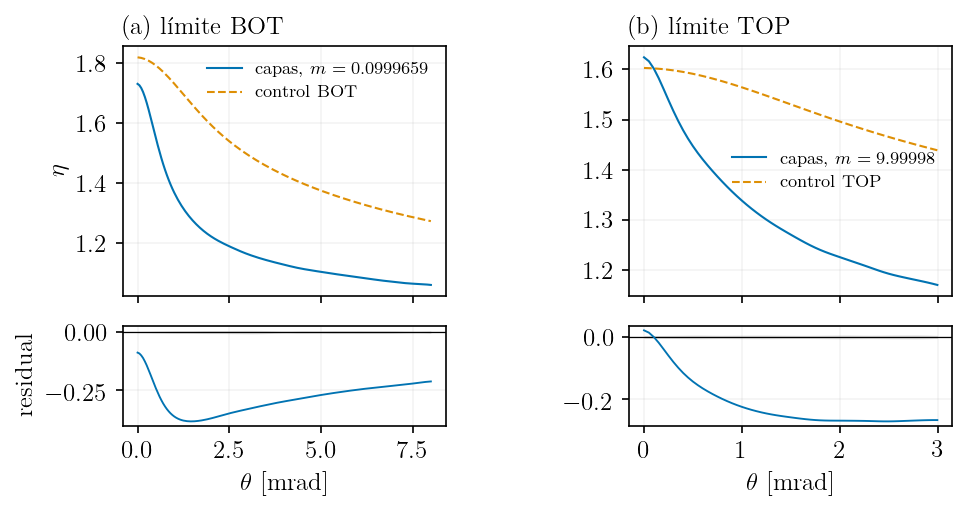


[!] El gate BOT falla. Revisa, en este orden:
    (1) desde donde se mide z_interface (superficie frontal vs otro origen)
    (2) si las especies TOP/BOT estan asignadas al reves en el script
    (3) si la capa BOT es realmente semi-infinita en la corrida

[!] El gate TOP falla. Revisa, en este orden:
    (1) desde donde se mide z_interface (superficie frontal vs otro origen)
    (2) si las especies TOP/BOT estan asignadas al reves en el script
    (3) si la capa BOT es realmente semi-infinita en la corrida


In [21]:
# ===========================================================================
# Gate: m_min vs BOT, m_max vs TOP
# ===========================================================================
GATE_TH = {"BOT": 8.0, "TOP": 3.0}          # mrad
GATE_STATS = {}

if CTRL:
    apply(width_frac=1.0)
    fig, axes = plt.subplots(2, 2, figsize=(TEXTWIDTH_IN, 0.52 * TEXTWIDTH_IN),
                             sharex="col",
                             gridspec_kw={"height_ratios": [3, 1.2], "hspace": 0.08,
                                          "wspace": 0.25})
    for col, (tag, g_lay) in enumerate((("BOT", G_THIN), ("TOP", G_THICK))):
        if tag not in CTRL:
            continue
        axp, axr = axes[0, col], axes[1, col]

        cur = [profile_one(sweep_L, kk, L_BOT)[1] for kk in g_lay.replicas_keys]
        th_l = profile_one(sweep_L, g_lay.replicas_keys[0], L_BOT)[0]
        E_l, S_l = np.vstack(cur).mean(0), np.vstack(cur).std(0, ddof=1)

        cur_c, th_c = [], None
        for kk in CTRL[tag]["keys"]:
            th_c, Ec = profile_one(sweep_M, kk, L_BOT)
            cur_c.append(Ec)
        E_c, S_c = np.vstack(cur_c).mean(0), np.vstack(cur_c).std(0, ddof=1)
        E_ci = np.interp(th_l, th_c, E_c)
        S_ci = np.interp(th_l, th_c, S_c)

        n_l, n_c = len(g_lay.replicas_keys), len(CTRL[tag]["keys"])
        se = np.sqrt(S_l ** 2 / n_l + S_ci ** 2 / n_c)
        w = th_l * 1e3 <= GATE_TH[tag]
        res = E_l - E_ci
        z = res[w] / np.where(se[w] > 0, se[w], np.inf)
        GATE_STATS[tag] = dict(chi2_bin=float(np.mean(z ** 2)),
                               rms=float(np.sqrt(np.mean(res[w] ** 2))))
        print(f"[gate {tag}] m={g_lay.mult:g} vs control: "
              f"chi2/bin = {GATE_STATS[tag]['chi2_bin']:.1f}   "
              f"RMS = {GATE_STATS[tag]['rms']:.2e}")
        print(f"           apice: capa {peak_height(E_l):.4f}  control {peak_height(E_ci):.4f}"
              f"   |  theta_1/2: {theta_level(th_l, E_l, 0.5)*1e3:.3f}  vs "
              f"{theta_level(th_l, E_ci, 0.5)*1e3:.3f} mrad")

        thm = th_l * 1e3
        axp.plot(thm[w], E_l[w], color=COL[0], lw=1.0, label=rf"capas, $m={g_lay.mult:g}$")
        axp.plot(thm[w], E_ci[w], "--", color=COL[1], lw=1.0, label=f"control {tag}")
        axp.set_title(f"({'ab'[col]}) límite {tag}", loc="left")
        axp.grid(alpha=0.15); axp.legend(fontsize="x-small", frameon=False)
        axr.axhline(0, c="k", lw=0.6)
        axr.fill_between(thm[w], -2 * se[w], 2 * se[w], color="gray", alpha=0.25, lw=0)
        axr.plot(thm[w], res[w], color=COL[0], lw=0.9)
        axr.set_xlabel(r"$\theta$ [mrad]"); axr.grid(alpha=0.15)
        if col == 0:
            axp.set_ylabel(r"$\eta$"); axr.set_ylabel("residual")

    fig.savefig(FIGDIR / "A1_gate_limites.pdf", bbox_inches="tight")
    plt.show()

    for tag in GATE_STATS:
        if GATE_STATS[tag]["rms"] > 5e-2:
            print(f"\n[!] El gate {tag} falla. Revisa, en este orden:")
            print("    (1) desde donde se mide z_interface (superficie frontal vs otro origen)")
            print("    (2) si las especies TOP/BOT estan asignadas al reves en el script")
            print("    (3) si la capa BOT es realmente semi-infinita en la corrida")

## L1 — Familia de perfiles

**Qué establece.** La fenomenología base, sin ningún ajuste: el perfil no es un cono de anchura
intermedia que interpola entre los dos constituyentes. El panel (a) muestra el cono completo, en la
escala del medio de menor $\ell^*$; el panel (b) amplía el ápice, donde vive la contribución de la
capa superior.

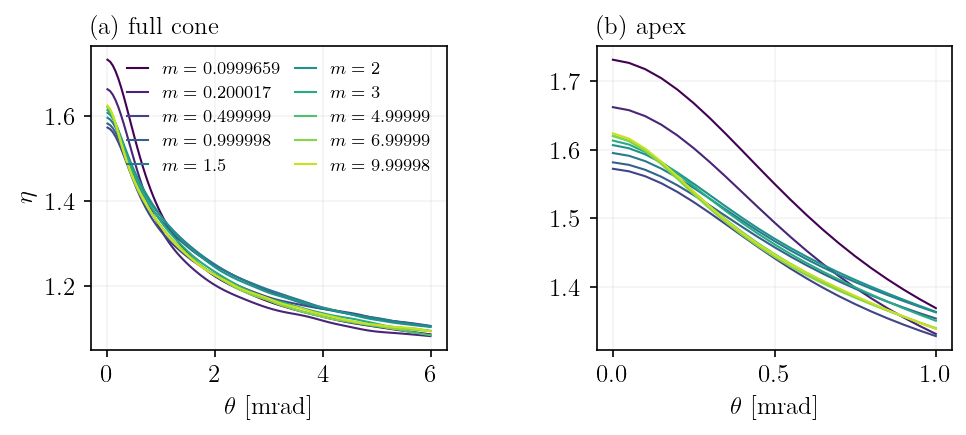

In [22]:
# ===========================================================================
# L1 -- familia eta(theta; m)
# ===========================================================================
apply(width_frac=1.0)
cmap = plt.cm.viridis(np.linspace(0.0, 0.92, len(GROUPS)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.44 * TEXTWIDTH_IN),
                               gridspec_kw={"wspace": 0.22})
PROF = {}
for c, g in zip(cmap, GROUPS):
    th, E = profile_sum(sweep_L, g.replicas_keys, L_BOT)
    PROF[g.mult] = (th, E)
    thm = th * 1e3
    for ax, tmax in ((ax1, CONV["th_full_mrad"]), (ax2, CONV["th_apex_mrad"])):
        msk = thm <= tmax
        ax.plot(thm[msk], E[msk], color=c, lw=1.0,
                label=rf"$m={g.mult:g}$" if ax is ax1 else None)

ax1.set_xlabel(r"$\theta$ [mrad]"); ax1.set_ylabel(r"$\eta$")
ax1.set_title(r"(a) full cone", loc="left")
ax1.grid(alpha=0.15)
ax1.legend(ncol=2, columnspacing=0.8, handlelength=1.2, fontsize="x-small", frameon=False)
ax2.set_xlabel(r"$\theta$ [mrad]")
ax2.set_title(r"(b) apex", loc="left")
ax2.grid(alpha=0.15)
fig.savefig(FIGDIR / "L1_familia_espesor.pdf", bbox_inches="tight")
plt.show()

## L2 — Test de autosimilitud: ¿existe un $\ell^*$ efectivo?

**Qué establece.** El resultado central, y es **libre de modelo**. Se normaliza cada perfil en
amplitud por $\eta(0)-1$ y en ángulo por su propia semianchura $\theta_{1/2}$, el ángulo donde el
exceso cae a la mitad:

$$\tilde f_m(u) = \frac{\eta(\theta;m)-1}{\eta(0;m)-1}, \qquad u = \theta/\theta_{1/2}(m).$$

Si el medio admite un $\ell^*$ efectivo, su perfil es $F(\theta/\ell^{*}_{\rm eff})$ para **alguna**
función $F$, y entonces todas las curvas normalizadas coinciden **exactamente**, sea cual sea $F$ y
sea cual sea $\ell^{*}_{\rm eff}$. Un perfil con dos escalas irreducibles no puede colapsar.

La prueba no supone la forma de línea de AWM ni depende del prefactor $C$, que ya se sabe que no es
el escalar en el canal lineal. Sobre familias sintéticas de una sola escala que recorren un factor 6
en $\ell^*$ la dispersión residual es $8\times10^{-4}$; sobre familias de dos escalas sube a
$1.9\times10^{-2}$, un factor 24. El mismo test se aplica a las once composiciones de §5.2, donde el
medio efectivo **sí** existe, y ese número es la referencia.

[L2] dispersion del colapso, bicapa  : 1.230e-02   (10 espesores)
[L2] dispersion del colapso, mezclas : 1.002e-03   (11 composiciones)
[L2] razon bicapa / mezcla = 12.3x


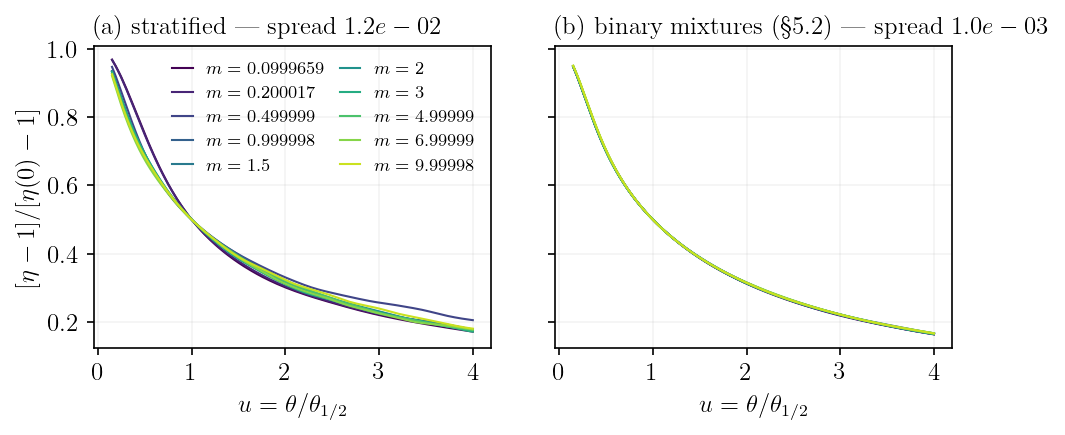

In [23]:
# ===========================================================================
# L2 -- colapso de autosimilitud, capas vs mezclas
# ===========================================================================
U_GRID = np.linspace(0.15, 4.0, 200)


def normalized_shape(theta, E, u_grid=U_GRID):
    """f(u) = [eta-1]/[eta(0)-1] contra u = theta / theta_(1/2)."""
    E0, th = peak_height(E), theta_level(theta, E, 0.5)
    if not np.isfinite(th) or th <= 0 or E0 <= 1.0:
        return np.full_like(u_grid, np.nan)
    return np.interp(u_grid, theta / th, (np.asarray(E) - 1.0) / (E0 - 1.0))


def collapse_residual(curves):
    """RMS de la dispersion entre curvas normalizadas."""
    C = np.vstack(curves)
    return float(np.sqrt(np.mean((C - C.mean(0)) ** 2)))


shapes_L = [normalized_shape(*PROF[g.mult]) for g in GROUPS]
rms_L = collapse_residual(shapes_L)

# --- referencia: las 11 composiciones de 5.2, mismo test -------------------
shapes_M, rms_M = [], np.nan
try:
    fr = np.linspace(0.0, 1.0, 11)
    for f in fr:
        kk = sorted(x for x in sweep_M.keys() if f"fraction_{f:.2f}" in x)
        l_f = float(sweep_M[kk[0]].params_flat["transport_mean_free_path"])
        th, E = profile_sum(sweep_M, kk, l_f)
        shapes_M.append(normalized_shape(th, E))
    rms_M = collapse_residual(shapes_M)
except Exception as err:
    print(f"[L2] referencia de mezclas no disponible: {err}")

print(f"[L2] dispersion del colapso, bicapa  : {rms_L:.3e}   ({len(shapes_L)} espesores)")
if np.isfinite(rms_M):
    print(f"[L2] dispersion del colapso, mezclas : {rms_M:.3e}   ({len(shapes_M)} composiciones)")
    print(f"[L2] razon bicapa / mezcla = {rms_L/rms_M:.1f}x")

apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.44 * TEXTWIDTH_IN),
                               sharey=True, gridspec_kw={"wspace": 0.12})

for c, (g, f) in zip(cmap, zip(GROUPS, shapes_L)):
    ax1.plot(U_GRID, f, color=c, lw=1.0, label=rf"$m={g.mult:g}$")
ax1.set_xlabel(r"$u = \theta/\theta_{1/2}$")
ax1.set_ylabel(r"$[\eta-1]/[\eta(0)-1]$")
ax1.set_title(rf"(a) stratified — spread ${rms_L:.1e}$", loc="left")
ax1.grid(alpha=0.15)
ax1.legend(ncol=2, columnspacing=0.8, handlelength=1.2, fontsize="x-small", frameon=False)

if shapes_M:
    for c, f in zip(plt.cm.viridis(np.linspace(0, 0.92, len(shapes_M))), shapes_M):
        ax2.plot(U_GRID, f, color=c, lw=1.0)
    ax2.set_title(rf"(b) binary mixtures (§5.2) — spread ${rms_M:.1e}$", loc="left")
ax2.set_xlabel(r"$u = \theta/\theta_{1/2}$")
ax2.grid(alpha=0.15)

fig.savefig(FIGDIR / "L2_autosimilitud.pdf", bbox_inches="tight")
plt.show()

## L3 — Escalares frente a profundidad

**Panel (a): la dilución del ápice deja de ser aditiva.** En §5.2, $\rho = 2-\eta(0)$ era exactamente
aditiva ($\chi^2/\mathrm{ndf}=0.70$) y quedaba siempre entre los valores de los dos constituyentes.
Aquí **sobrepasa a ambos**, con un máximo a espesor intermedio. El mecanismo es directo: una capa
superior más delgada que su propia longitud de transporte aporta dispersión simple sin aportar
difusión, y la atenuación del fondo se cancela en el cociente porque afecta por igual al numerador y
al denominador. Cuando $d \gtrsim \ell^*_{\rm top}$ la capa empieza a difundir por su cuenta y $\rho$
relaja hacia su valor homogéneo.

**Panel (b): el invariante de forma.** En lugar de una FWHM —que en un perfil de dos escalas salta
entre rasgos y produce una serie no monótona sin significado— se reporta

$$S = \frac{\theta_{0.25}}{\theta_{0.75}},$$

la razón entre los ángulos donde el exceso cae al 25 % y al 75 % del ápice. Es una razón de dos
escalas del **mismo** perfil, así que es independiente de la escala: cualquier medio descrito por un
único $\ell^*$ da el mismo $S$, cualquiera que sea su $\ell^*$ (verificado sobre familias sintéticas:
$S$ varía un 2.6 % al recorrer un factor 6 en $\ell^*$). Que $S$ se aparte, y que lo haga con un
máximo a espesor intermedio, es la misma firma de dos escalas que $\rho$, sobre un observable
independiente. La curva de §5.2 sirve de control: allí $S$ debe ser plano.

[L3] rho: extremos 0.2731 (m=0.0999659) y 0.3838 (m=9.99998)
     maximo 0.4311 en m = 0.499999   -> sobrepasa ambos por +12.3 %  (19.3 sigma)
     rho satura (2 % de su valor final) desde m ~ 4.99999
[L3] S: extremos 5.171 y 7.484   maximo 7.675 en m = 0.499999
[L3] control 5.2: S = 6.215 +/- 0.035   (dispersion 0.6 %)


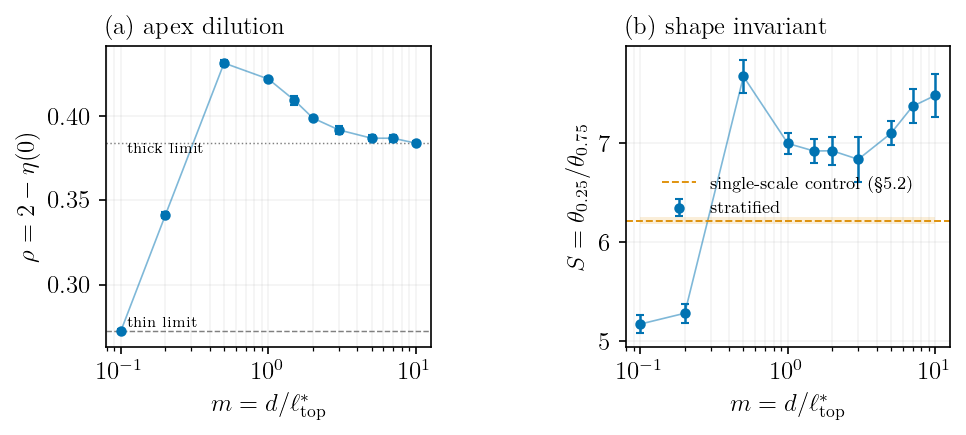


[L3] FWHM (SOLO tabla; no es un ancho en un perfil de dos escalas):
     2.04  2.02  2.67  3.04  3.03  2.86  2.63  2.41  2.45  2.39


In [24]:
# ===========================================================================
# L3 -- rho(m) e invariante de forma S(m)
# ===========================================================================
rows_mean, rows_se = [], []
for g in GROUPS:
    mu, se = scalars_over_replicas(sweep_L, g, L_BOT)
    rows_mean.append(mu); rows_se.append(se)
MEAN, SE = np.asarray(rows_mean), np.asarray(rows_se)
E0, TH, SH, FW = MEAN.T
sE0, sTH, sSH, sFW = SE.T
RHO, sRHO = 2.0 - E0, sE0

i_max = int(np.argmax(RHO))
z_over = (RHO[i_max] - max(RHO[0], RHO[-1])) / np.sqrt(sRHO[i_max] ** 2 + max(sRHO[0], sRHO[-1]) ** 2)
print(f"[L3] rho: extremos {RHO[0]:.4f} (m={MULTS[0]:g}) y {RHO[-1]:.4f} (m={MULTS[-1]:g})")
print(f"     maximo {RHO[i_max]:.4f} en m = {MULTS[i_max]:g}"
      f"   -> sobrepasa ambos por {100*(RHO[i_max]/max(RHO[0],RHO[-1])-1):+.1f} %"
      f"  ({z_over:.1f} sigma)")

sat = np.where(np.abs(RHO / RHO[-1] - 1) < 0.02)[0]
M_SAT = MULTS[sat[0]] if len(sat) else np.nan
print(f"     rho satura (2 % de su valor final) desde m ~ {M_SAT:g}")

j_max = int(np.nanargmax(SH))
print(f"[L3] S: extremos {SH[0]:.3f} y {SH[-1]:.3f}   maximo {SH[j_max]:.3f} en m = {MULTS[j_max]:g}")

# --- control: S sobre las composiciones de 5.2 (debe ser plano) -----------
SH_MIX = []
try:
    for f in np.linspace(0.0, 1.0, 11):
        kk = sorted(x for x in sweep_M.keys() if f"fraction_{f:.2f}" in x)
        l_f = float(sweep_M[kk[0]].params_flat["transport_mean_free_path"])
        th, E = profile_sum(sweep_M, kk, l_f)
        SH_MIX.append(shape_invariant(th, E))
    SH_MIX = np.asarray(SH_MIX)
    print(f"[L3] control 5.2: S = {np.nanmean(SH_MIX):.3f} +/- {np.nanstd(SH_MIX, ddof=1):.3f}"
          f"   (dispersion {100*np.nanstd(SH_MIX, ddof=1)/np.nanmean(SH_MIX):.1f} %)")
except Exception as err:
    SH_MIX = np.array([])
    print(f"[L3] control de mezclas no disponible: {err}")

apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.44 * TEXTWIDTH_IN),
                               gridspec_kw={"wspace": 0.28})

ax1.errorbar(MULTS, RHO, sRHO, fmt="o", ms=4, capsize=2, color=COL[0], ls="none")
ax1.plot(MULTS, RHO, "-", color=COL[0], lw=0.8, alpha=0.5)
ax1.axhline(RHO[0],  ls="--", c="gray", lw=0.7)
ax1.axhline(RHO[-1], ls=":",  c="gray", lw=0.7)
ax1.annotate("thin limit",  (MULTS[0] * 1.1, RHO[0]),  fontsize=7, va="bottom")
ax1.annotate("thick limit", (MULTS[0] * 1.1, RHO[-1]), fontsize=7, va="top")
ax1.set_xscale("log")
ax1.set_xlabel(r"$m = d/\ell^*_{\rm top}$")
ax1.set_ylabel(r"$\rho = 2 - \eta(0)$")
ax1.set_title("(a) apex dilution", loc="left")
ax1.grid(alpha=0.15, which="both")

ax2.errorbar(MULTS, SH, sSH, fmt="o", ms=4, capsize=2, color=COL[0], ls="none",
             label="stratified")
ax2.plot(MULTS, SH, "-", color=COL[0], lw=0.8, alpha=0.5)
if len(SH_MIX):
    mu_s = float(np.nanmean(SH_MIX)); sd_s = float(np.nanstd(SH_MIX, ddof=1))
    ax2.axhline(mu_s, ls="--", color=COL[1], lw=0.9,
                label=r"single-scale control (§5.2)")
    ax2.fill_between([MULTS.min(), MULTS.max()], mu_s - sd_s, mu_s + sd_s,
                     color=COL[1], alpha=0.15, lw=0)
ax2.set_xscale("log")
ax2.set_xlabel(r"$m = d/\ell^*_{\rm top}$")
ax2.set_ylabel(r"$S = \theta_{0.25}/\theta_{0.75}$")
ax2.set_title("(b) shape invariant", loc="left")
ax2.grid(alpha=0.15, which="both")
ax2.legend(fontsize="x-small", frameon=False)

fig.savefig(FIGDIR / "L3_escalares_vs_d.pdf", bbox_inches="tight")
plt.show()

print("\n[L3] FWHM (SOLO tabla; no es un ancho en un perfil de dos escalas):")
print("     " + "  ".join(f"{v:.2f}" for v in FW))

## L4 — Contraste tardío: el compuerteo temporal extiende la profundidad

**Qué establece.** Que la ventana temporal añade selectividad donde el régimen estacionario ya saturó.

Se mide $\theta_{1/2}(t)$ por bin temporal —la semianchura, con las intensidades sumadas sobre réplicas,
porque los bins tardíos tienen pocos fotones— y se forma el cociente contra la referencia de capa gruesa,
$R_m(t) = \theta_{1/2,m}(t)/\theta_{1/2,\rm ref}(t)$. Si los fotones alcanzan el fondo dentro de la
ventana, el cono se ensancha y $R$ sube; si la interfaz queda fuera de alcance, $R\to1$.

**No se ajusta $t^*$ ni la ley $t^*\propto d^2$.** El observable es el contraste tardío $R_{\rm late}$
frente al espesor, que es monótono y define directamente la profundidad de sondeo.

m=  0.10:  99 bins temporales validos
m=  0.20:  99 bins temporales validos
m=  0.50:  99 bins temporales validos
m=  1.00:  99 bins temporales validos
m=  1.50:  99 bins temporales validos
m=  2.00:  99 bins temporales validos
m=  3.00:  98 bins temporales validos
m=  5.00:  99 bins temporales validos
m=  7.00:  99 bins temporales validos
m= 10.00:  99 bins temporales validos

[L4] contraste tardio R vs referencia m=9.99998:
     m=  0.10   R_late = 1.946
     m=  0.20   R_late = 1.892
     m=  0.50   R_late = 1.723
     m=  1.00   R_late = 1.569
     m=  1.50   R_late = 1.428
     m=  2.00   R_late = 1.354
     m=  3.00   R_late = 1.174
     m=  5.00   R_late = 0.975
     m=  7.00   R_late = 0.958
[L4] R_late cruza 1.10 en m ~ 3.6  -> profundidad de sondeo temporal


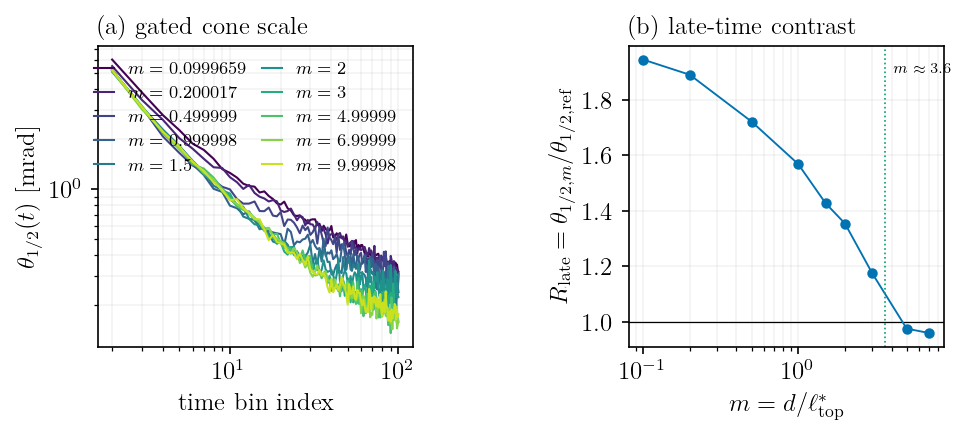

In [25]:
# ===========================================================================
# L4 -- theta_(1/2)(t) por espesor y contraste tardio
# ===========================================================================
N_TIME_BINS  = 100          # bin 0 = integrado
TIME_STRIDE  = 1
SNR_MIN      = 5.0
FRAC_LATE    = 0.20         # fraccion final de bins que define "tardio"


def estimate_noise(theta, E, th_min_mrad=None):
    th_min_mrad = th_min_mrad or CONV["th_full_mrad"]
    m = theta * 1e3 > th_min_mrad
    return float(np.std(E[m])) if np.count_nonzero(m) > 5 else np.inf


WID = {}
for g in GROUPS:
    ts, tc = [], []   # tc = theta_(1/2) por bin temporal
    for it in range(1, N_TIME_BINS + 1, TIME_STRIDE):
        try:
            th, E = profile_sum(sweep_L, g.replicas_keys, L_BOT, time_index=int(it))
        except Exception:
            continue
        e0 = peak_height(E)
        if not np.isfinite(e0) or (e0 - 1.0) < SNR_MIN * estimate_noise(th, E):
            continue
        c = theta_level(th, E, 0.5)
        if np.isfinite(c):
            ts.append(it); tc.append(c * 1e3)
    WID[g.mult] = (np.asarray(ts, float), np.asarray(tc))
    print(f"m={g.mult:6.2f}: {len(ts):3d} bins temporales validos")

ref_m = GROUPS[-1].mult
ts_r, tc_r = WID[ref_m]

R_LATE, M_R = [], []
for g in GROUPS[:-1]:
    ts, tc = WID[g.mult]
    if len(ts) < 8 or len(ts_r) < 8:
        continue
    lo, hi = max(ts.min(), ts_r.min()), min(ts.max(), ts_r.max())
    msk = (ts >= lo) & (ts <= hi)
    R = tc[msk] / np.interp(ts[msk], ts_r, tc_r)
    n_late = max(3, int(FRAC_LATE * len(R)))
    R_LATE.append(float(np.median(R[-n_late:])))
    M_R.append(g.mult)
R_LATE, M_R = np.asarray(R_LATE), np.asarray(M_R)

print(f"\n[L4] contraste tardio R vs referencia m={ref_m:g}:")
for mi, ri in zip(M_R, R_LATE):
    print(f"     m={mi:6.2f}   R_late = {ri:.3f}")

crossing = np.nan
for a, b in zip(range(len(M_R) - 1), range(1, len(M_R))):
    if (R_LATE[a] - 1.10) * (R_LATE[b] - 1.10) < 0:
        crossing = float(np.exp(np.interp(1.10, [R_LATE[b], R_LATE[a]],
                                          np.log([M_R[b], M_R[a]]))))
        break
print(f"[L4] R_late cruza 1.10 en m ~ {crossing:.1f}  -> profundidad de sondeo temporal")

apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.44 * TEXTWIDTH_IN),
                               gridspec_kw={"wspace": 0.28})

for c, g in zip(cmap, GROUPS):
    ts, tc = WID[g.mult]
    if len(ts):
        ax1.plot(ts, tc, "-", color=c, lw=1.0, label=rf"$m={g.mult:g}$")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"time bin index")
ax1.set_ylabel(r"$\theta_{1/2}(t)$ [mrad]")
ax1.set_title("(a) gated cone scale", loc="left")
ax1.grid(alpha=0.15, which="both")
ax1.legend(ncol=2, columnspacing=0.8, handlelength=1.2, fontsize="x-small", frameon=False)

ax2.axhline(1.0, c="k", lw=0.6)
ax2.plot(M_R, R_LATE, "o-", ms=4, color=COL[0], lw=0.9)
if np.isfinite(crossing):
    ax2.axvline(crossing, ls=":", color=COL[2], lw=0.8)
    ax2.annotate(rf"$m \approx {crossing:.1f}$", (crossing, R_LATE.max()),
                 textcoords="offset points", xytext=(4, -6), fontsize=7)
ax2.set_xscale("log")
ax2.set_xlabel(r"$m = d/\ell^*_{\rm top}$")
ax2.set_ylabel(r"$R_{\rm late} = \theta_{1/2,m}/\theta_{1/2,\rm ref}$")
ax2.set_title("(b) late-time contrast", loc="left")
ax2.grid(alpha=0.15, which="both")

fig.savefig(FIGDIR / "L4_contraste_tardio.pdf", bbox_inches="tight")
plt.show()

### Verificación de la grilla temporal

El eje de L4(a) está en **índice de bin**, no en tiempo físico, a propósito: el notebook exploratorio
reconstruía los bordes temporales porque no los encontraba en `params_flat`, y una grilla reconstruida
mal invalida cualquier eje en $\tau^*$. Esta celda localiza la grilla real. Mientras no cuadre, L4 se
presenta en índice de bin — el contraste tardío frente al espesor no depende de la calibración
absoluta del tiempo.

In [26]:
# ===========================================================================
# Diagnostico de la grilla temporal
# ===========================================================================
_p = sweep_L[G_THIN.replicas_keys[0]].params_flat
cand = {kk: _p[kk] for kk in _p
        if any(s in kk.lower() for s in ("time", "tau", "dt", "t_max", "tmax", "bins"))}
print("claves temporales en params_flat:")
for kk, v in cand.items():
    print(f"  {kk:38s} = {v}")
if not cand:
    print("  (ninguna)")

try:
    from utils.time import build_time_grid
    print("\nutils.time.build_time_grid disponible -- reconstruye la grilla con los "
          "mismos argumentos del script de generacion y compara con las claves de arriba.")
except Exception as err:
    print(f"\n[grid] utils.time no importable: {err}")

print(f"\nreferencia: tau*_top = l*_top / v = {TAU_TOP_FS:.1f} fs")
print(f"            en convencion de camino geometrico, tau*_top = {L_TOP:.1f} um")
print("Para que la interfaz sea alcanzable a espesor m se necesita t_max >~ 1.5 m^2 tau*_top:")
for mi in (0.5, 1.0, 2.0, 5.0):
    print(f"   m = {mi:4.1f}  ->  t_max >~ {1.5*mi**2*TAU_TOP_FS/1e3:8.2f} ps "
          f"= {1.5*mi**2*L_TOP:9.0f} um de camino")

claves temporales en params_flat:
  d_time                                 = 47.176076057192006
  l_star_time_anchor                     = 117.94019014298
  t_max                                  = 4717.6076057192
  time_anchor                            = max_lstar (top)

utils.time.build_time_grid disponible -- reconstruye la grilla con los mismos argumentos del script de generacion y compara con las claves de arriba.

referencia: tau*_top = l*_top / v = 523.2 fs
            en convencion de camino geometrico, tau*_top = 117.9 um
Para que la interfaz sea alcanzable a espesor m se necesita t_max >~ 1.5 m^2 tau*_top:
   m =  0.5  ->  t_max >~     0.20 ps =        44 um de camino
   m =  1.0  ->  t_max >~     0.78 ps =       177 um de camino
   m =  2.0  ->  t_max >~     3.14 ps =       708 um de camino
   m =  5.0  ->  t_max >~    19.62 ps =      4423 um de camino


## Tabla y números citables

In [27]:
# ===========================================================================
# Tabla -> CSV + filas LaTeX
# ===========================================================================
R_map = {mi: ri for mi, ri in zip(M_R, R_LATE)}
df = pd.DataFrame({
    "m": MULTS,
    "d_um": [g.z for g in GROUPS],
    "eta0": E0, "s_eta0": sE0,
    "rho": RHO, "s_rho": sRHO,
    "theta_half_mrad": TH, "s_theta_half": sTH,
    "S_shape": SH, "s_S_shape": sSH,
    "FWHM_mrad": FW,
    "R_late": [R_map.get(mi, np.nan) for mi in MULTS],
})
df.to_csv(FIGDIR / "tabla_capas.csv", index=False)
display(df.round(4))


def pm(v, s, nd=4):
    return "--" if not np.isfinite(v) else rf"${v:.{nd}f} \pm {s:.{nd}f}$"


lines = ["    " + " & ".join([
    f"{r['m']:g}", f"{r['d_um']:.0f}",
    pm(r["rho"], r["s_rho"], 4),
    pm(r["theta_half_mrad"], r["s_theta_half"], 3),
    pm(r["S_shape"], r["s_S_shape"], 3),
    "--" if not np.isfinite(r["R_late"]) else f"{r['R_late']:.2f}",
]) + r" \\" for _, r in df.iterrows()]
(FIGDIR / "tabla_capas.tex").write_text("\n".join(lines))
print("\n".join(lines))

,m,d_um,eta0,s_eta0,rho,s_rho,theta_half_mrad,s_theta_half,S_shape,s_S_shape,FWHM_mrad,R_late
0,0.1,11.79,1.7269,0.0014,0.2731,0.0014,1.0199,0.0085,5.1711,0.0913,2.0398,1.9465
1,0.2,23.59,1.6586,0.0015,0.3414,0.0015,1.0100,0.0085,5.2805,0.0976,2.0200,1.8916
2,0.5,58.97,1.5689,0.0020,0.4311,0.0020,1.3355,0.0149,7.6755,0.1706,2.6709,1.7225
3,1.0,117.94,1.5784,0.0014,0.4216,0.0014,1.5218,0.0411,6.9978,0.1050,3.0436,1.5689
4,1.5,176.91,1.5909,0.0026,0.4091,0.0026,1.5137,0.0235,6.9216,0.1241,3.0274,1.4276
5,2.0,235.88,1.6014,0.0012,0.3986,0.0012,1.4317,0.0157,6.9238,0.1391,2.8634,1.3542
6,3.0,353.82,1.6084,0.0022,0.3916,0.0022,1.3168,0.0230,6.8372,0.2305,2.6335,1.1741
7,5.0,589.70,1.6133,0.0018,0.3867,0.0018,1.2061,0.0061,7.1004,0.1227,2.4122,0.9745
8,7.0,825.58,1.6133,0.0021,0.3867,0.0021,1.2266,0.0184,7.3731,0.1732,2.4532,0.9583
9,10.0,1179.40,1.6162,0.0013,0.3838,0.0013,1.1933,0.0127,7.4845,0.2199,2.3866,NaN


    0.0999659 & 12 & $0.2731 \pm 0.0014$ & $1.020 \pm 0.009$ & $5.171 \pm 0.091$ & 1.95 \\
    0.200017 & 24 & $0.3414 \pm 0.0015$ & $1.010 \pm 0.008$ & $5.281 \pm 0.098$ & 1.89 \\
    0.499999 & 59 & $0.4311 \pm 0.0020$ & $1.335 \pm 0.015$ & $7.675 \pm 0.171$ & 1.72 \\
    0.999998 & 118 & $0.4216 \pm 0.0014$ & $1.522 \pm 0.041$ & $6.998 \pm 0.105$ & 1.57 \\
    1.5 & 177 & $0.4091 \pm 0.0026$ & $1.514 \pm 0.023$ & $6.922 \pm 0.124$ & 1.43 \\
    2 & 236 & $0.3986 \pm 0.0012$ & $1.432 \pm 0.016$ & $6.924 \pm 0.139$ & 1.35 \\
    3 & 354 & $0.3916 \pm 0.0022$ & $1.317 \pm 0.023$ & $6.837 \pm 0.230$ & 1.17 \\
    4.99999 & 590 & $0.3867 \pm 0.0018$ & $1.206 \pm 0.006$ & $7.100 \pm 0.123$ & 0.97 \\
    6.99999 & 826 & $0.3867 \pm 0.0021$ & $1.227 \pm 0.018$ & $7.373 \pm 0.173$ & 0.96 \\
    9.99998 & 1179 & $0.3838 \pm 0.0013$ & $1.193 \pm 0.013$ & $7.484 \pm 0.220$ & -- \\


In [28]:
# ===========================================================================
# Resumen citable
# ===========================================================================
print("=" * 72)
print("NUMEROS CITABLES 5.3 (bicapa)")
print("=" * 72)
print(f"  sistema: l*_top = {L_TOP:.1f} um, l*_bot = {L_BOT:.1f} um, razon {L_TOP/L_BOT:.2f}")
for tag, st in GATE_STATS.items():
    print(f"  gate {tag:3s}: chi2/bin = {st['chi2_bin']:8.1f}   RMS = {st['rms']:.2e}")

print(f"\n  L2  autosimilitud: dispersion bicapa = {rms_L:.2e}")
if np.isfinite(rms_M):
    print(f"      referencia mezclas (5.2)      = {rms_M:.2e}   -> razon {rms_L/rms_M:.1f}x")
print("      -> un cono de una sola escala colapsa exactamente; la bicapa no")

print(f"\n  L3  rho: {RHO[0]:.4f} (delgada) -> max {RHO[i_max]:.4f} en m={MULTS[i_max]:g}"
      f" -> {RHO[-1]:.4f} (gruesa)")
print(f"      sobrepaso sobre ambos extremos: {z_over:.1f} sigma"
      f"   ({100*(RHO[i_max]/max(RHO[0],RHO[-1])-1):+.1f} %)")
print(f"      saturacion estacionaria desde m ~ {M_SAT:g}")
print(f"      S: extremos {SH[0]:.3f} / {SH[-1]:.3f}, maximo {SH[j_max]:.3f} en m={MULTS[j_max]:g}")
if len(SH_MIX):
    print(f"      control de una sola escala (5.2): S = {np.nanmean(SH_MIX):.3f} "
          f"+/- {np.nanstd(SH_MIX, ddof=1):.3f}")

print(f"\n  L4  contraste tardio: {R_LATE.max():.2f} (m={M_R[np.argmax(R_LATE)]:g}) "
      f"-> {R_LATE.min():.2f} (m={M_R[np.argmin(R_LATE)]:g}), monotono")
print(f"      cruza 1.10 en m ~ {crossing:.1f}: el compuerteo temporal sigue viendo la")
print(f"      interfaz donde el estacionario ya saturo (m ~ {M_SAT:g})")
print("=" * 72)

for p in sorted(FIGDIR.glob("*")):
    print(f"  {p.name:30s}  {p.stat().st_size/1024:7.1f} kB")

NUMEROS CITABLES 5.3 (bicapa)
  sistema: l*_top = 117.9 um, l*_bot = 23.2 um, razon 5.09
  gate BOT: chi2/bin =  11390.1   RMS = 2.92e-01
  gate TOP: chi2/bin =   6658.0   RMS = 2.31e-01

  L2  autosimilitud: dispersion bicapa = 1.23e-02
      referencia mezclas (5.2)      = 1.00e-03   -> razon 12.3x
      -> un cono de una sola escala colapsa exactamente; la bicapa no

  L3  rho: 0.2731 (delgada) -> max 0.4311 en m=0.499999 -> 0.3838 (gruesa)
      sobrepaso sobre ambos extremos: 19.3 sigma   (+12.3 %)
      saturacion estacionaria desde m ~ 4.99999
      S: extremos 5.171 / 7.484, maximo 7.675 en m=0.499999
      control de una sola escala (5.2): S = 6.215 +/- 0.035

  L4  contraste tardio: 1.95 (m=0.0999659) -> 0.96 (m=6.99999), monotono
      cruza 1.10 en m ~ 3.6: el compuerteo temporal sigue viendo la
      interfaz donde el estacionario ya saturo (m ~ 4.99999)
  A1_gate_limites.pdf               329.6 kB
  L1_familia_espesor.pdf            305.4 kB
  L2_autosimilitud.pdf        

---

## Qué se quitó, y por qué

Para el registro, en caso de que quieras recuperar algo si aparece tiempo:

**Ley $t^{*} \propto d^{2}$ y la inversión temporal del espesor.** La ventana temporal de la campaña
actual cubre $\sim 0.2\,\tau^{*}_{\rm top}$, mientras que la predicción sitúa el quiebre en
$1.5\,m^{2}\tau^{*}_{\rm top}$ — cuatro veces fuera de la ventana ya para $m=1$. Todos los $t^{*}$
caen en el primer bin y el ajuste devuelve $\alpha \approx 0$. Requiere volver a correr con
$t_{\max}$ unas cincuenta veces mayor; con eso $m \le 2$ sería alcanzable.

**Descomposición en dos conos, $w(m)$ y $\zeta$.** Las dos bases medidas resultan casi colineales
($\theta_c$ de los dos controles difiere mucho menos que el factor $\ell^{*}_{\rm top}/\ell^{*}_{\rm bot}$
que la teoría exige), así que la regresión está mal condicionada: $w$ sale no monótona y por encima
de 1. El $\zeta$ ajustado no es una medida. Recuperable solo si el gate se arregla y los extremos del
barrido alcanzan de verdad los dos límites homogéneos.

**Saturación exponencial de $\rho$ con escala $m_\rho$.** El modelo es monótono y $\rho$ no lo es.
El no-monotonismo es el resultado, no un defecto del ajuste.